In [1]:
from pathlib import Path
import torchvision.transforms as transforms
import os, sys
#===========================================
# Path to dataset
#===========================================
project_path = Path('/home/asus/DATA/VAD')
ped2_dataset_folder = Path('/home/dataset/ped2')
train_dir = ped2_dataset_folder / 'training'
test_dir = ped2_dataset_folder / 'testing'

if train_dir.is_dir():
    print(f"{train_dir} directory exists.")
    
# adding project folder to the system path
sys.path.insert(0, '/home/asus/DATA/VAD')

/home/dataset/ped2/training directory exists.


In [2]:
from dataset.process import get_train_dataset
from dataset.samples import get_cifar100_dataset
from dataset.aug import patch_SmoothMixS
from dataset.plot import *

from torchvision.datasets import CIFAR100
from model.util.process_data import decode_clip_cat
from system.PAMAE6.default import update_config, cfg

print('cfg.DATASET.path = ', cfg.DATASET.path)
print('cfg.DATASET.name = ', cfg.DATASET.name)
print('cfg.DATASET.num_frames = ', cfg.DATASET.num_frames)
print('cfg.DATASET.frame_steps = ', cfg.DATASET.frame_steps)
cfg.DATASET.name = "ped2_tiny"
cfg.DATASET.train.batch_size_per_gpu = 4

train_dataset, train_dataloader = get_train_dataset(cfg)
cifar100_dataset, cifar100_dataloader = get_cifar100_dataset(cfg)
print(f'len(train_dataset) = {len(train_dataset)}')
print(f'len(cifar100_dataset) = {len(cifar100_dataset)}')

cifar_iter = iter(cifar100_dataloader)
train_iter = iter(train_dataloader)

data_cifar, _ = next(cifar_iter)
data_train = next(train_iter)

#print('data_cifar.shape = ', data_cifar.shape) # torch.Size([1, 3, 32, 32])
print(f'len(data_cifar) = {len(data_cifar)}')
print('data_cifar.shape = ', data_cifar.shape) # torch.Size([1, 3, 32, 32])

print(f'len(data_train) = {len(data_train)}')
print('data_train.shape = ', data_train.shape)

project_home=/home/asus/DATA/VAD existed in sys.path!
cfg.DATASET.path =  /home/dataset
cfg.DATASET.name =  ped2
cfg.DATASET.num_frames =  5
cfg.DATASET.frame_steps =  1
The directory '/home/dataset/ped2_tiny/training' exists and is a directory.
dirs =  ['/home/dataset/ped2_tiny/training', '/home/dataset/ped2_tiny/training/01', '/home/dataset/ped2_tiny/training/02']
Files already downloaded and verified
len(train_dataset) = 262
len(cifar100_dataset) = 50000
len(data_cifar) = 1
data_cifar.shape =  torch.Size([1, 3, 32, 32])
len(data_train) = 4
data_train.shape =  torch.Size([4, 15, 256, 256])


imgs.shape =  torch.Size([1, 12, 256, 256])
target.shape =  torch.Size([1, 3, 256, 256])


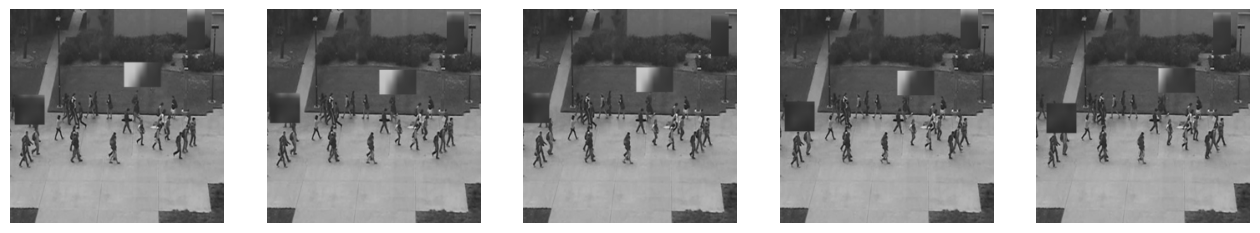

In [5]:
bz = cfg.DATASET.train.batch_size_per_gpu # 4
data_train[0], mask = patch_SmoothMixS(data_train[0].unsqueeze(0), #torch.Size([15, 256, 256])
                                            data_cifar.squeeze(0), #torch.Size([3, 32, 32])
                                            #data_cifar, 
                                             max_size=0.2, 
                                             h=256, w=256, 
                                             max_move=10)

imgs, target = decode_clip_cat(data=data_train[0].unsqueeze(0), 
                               model_type=cfg.MODEL.type,
                               num_frames=cfg.DATASET.num_frames,
                               channel=cfg.DATASET.channel)
print('imgs.shape = ', imgs.shape) # torch.Size([1, 12, 256, 256])
print('target.shape = ', target.shape) # torch.Size([1, 3, 256, 256])
Plot_clip_tensor(data_train[0].unsqueeze(0))
    

In [19]:
import natsort

root = '/home/dataset/avenue/testing'
#dirs = [x[0] for x in os.walk(root, followlinks=True)]
dirs = [os.path.join(root, x) for x in os.listdir(root)]
dirs = natsort.natsorted(dirs) 
print('dirs = ', dirs)
print('len(dirs) =', len(dirs))

dirs =  ['/home/dataset/avenue/testing/01', '/home/dataset/avenue/testing/02', '/home/dataset/avenue/testing/03', '/home/dataset/avenue/testing/04', '/home/dataset/avenue/testing/05', '/home/dataset/avenue/testing/06', '/home/dataset/avenue/testing/07', '/home/dataset/avenue/testing/08', '/home/dataset/avenue/testing/09', '/home/dataset/avenue/testing/10', '/home/dataset/avenue/testing/11', '/home/dataset/avenue/testing/12', '/home/dataset/avenue/testing/13', '/home/dataset/avenue/testing/14', '/home/dataset/avenue/testing/15', '/home/dataset/avenue/testing/16', '/home/dataset/avenue/testing/17', '/home/dataset/avenue/testing/18', '/home/dataset/avenue/testing/19', '/home/dataset/avenue/testing/20', '/home/dataset/avenue/testing/21']
len(dirs) = 21


In [19]:
import natsort

root = '/home/dataset/avenue/testing'
#dirs = [x[0] for x in os.walk(root, followlinks=True)]
dirs = [os.path.join(root, x) for x in os.listdir(root)]
dirs = natsort.natsorted(dirs) 
print('dirs = ', dirs)
print('len(dirs) =', len(dirs))

dirs =  ['/home/dataset/avenue/testing/01', '/home/dataset/avenue/testing/02', '/home/dataset/avenue/testing/03', '/home/dataset/avenue/testing/04', '/home/dataset/avenue/testing/05', '/home/dataset/avenue/testing/06', '/home/dataset/avenue/testing/07', '/home/dataset/avenue/testing/08', '/home/dataset/avenue/testing/09', '/home/dataset/avenue/testing/10', '/home/dataset/avenue/testing/11', '/home/dataset/avenue/testing/12', '/home/dataset/avenue/testing/13', '/home/dataset/avenue/testing/14', '/home/dataset/avenue/testing/15', '/home/dataset/avenue/testing/16', '/home/dataset/avenue/testing/17', '/home/dataset/avenue/testing/18', '/home/dataset/avenue/testing/19', '/home/dataset/avenue/testing/20', '/home/dataset/avenue/testing/21']
len(dirs) = 21


In [20]:
import natsort

root = '/home/dataset/avenue/testing'
dirs = [x[0] for x in os.walk(root, followlinks=True)]
dirs = natsort.natsorted(dirs) 
print('dirs = ', dirs)
print('len(dirs) =', len(dirs))

dirs =  ['/home/dataset/avenue/testing', '/home/dataset/avenue/testing/01', '/home/dataset/avenue/testing/02', '/home/dataset/avenue/testing/03', '/home/dataset/avenue/testing/04', '/home/dataset/avenue/testing/05', '/home/dataset/avenue/testing/06', '/home/dataset/avenue/testing/07', '/home/dataset/avenue/testing/08', '/home/dataset/avenue/testing/09', '/home/dataset/avenue/testing/09/.ipynb_checkpoints', '/home/dataset/avenue/testing/10', '/home/dataset/avenue/testing/11', '/home/dataset/avenue/testing/12', '/home/dataset/avenue/testing/13', '/home/dataset/avenue/testing/14', '/home/dataset/avenue/testing/15', '/home/dataset/avenue/testing/16', '/home/dataset/avenue/testing/17', '/home/dataset/avenue/testing/18', '/home/dataset/avenue/testing/19', '/home/dataset/avenue/testing/20', '/home/dataset/avenue/testing/21']
len(dirs) = 23


In [21]:
ls = [0, 1, 2, 3, 4, 5, 6]
print(ls[:4])
print(ls[4:])

[0, 1, 2, 3]
[4, 5, 6]
